<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/notebooks/SkinLesionTriage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproducible Pipeline

In [4]:
#metadaten als auch images sind in drive gespeichert
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Mounted at /content/drive


In [1]:
#set seed for reproducibility
random_state = 42

# Data Exploration

In [ ]:
# load metadata
csv_path = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_metadata.csv'
df = pd.read_csv(csv_path)

# 'mel' (melanoma) = 1, benign = 0
df['label'] = (df['dx'] == 'mel').astype(int)

print(f"Shape der Daten : {df.shape}")
print(f"Anzahl der Dimensionen : {df.ndim}")
print("\nVerteilung der Klassen (0=Gutartig, 1=Melanom):")
print(df['label'].value_counts())

print("\nDie ersten 5 Zeilen (Head):")
df.head()

Shape der Daten : (10015, 8)
Anzahl der Dimensionen : 2

Verteilung der Klassen (0=Gutartig, 1=Melanom):
label
0    8902
1    1113
Name: count, dtype: int64

Die ersten 5 Zeilen (Head):


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0


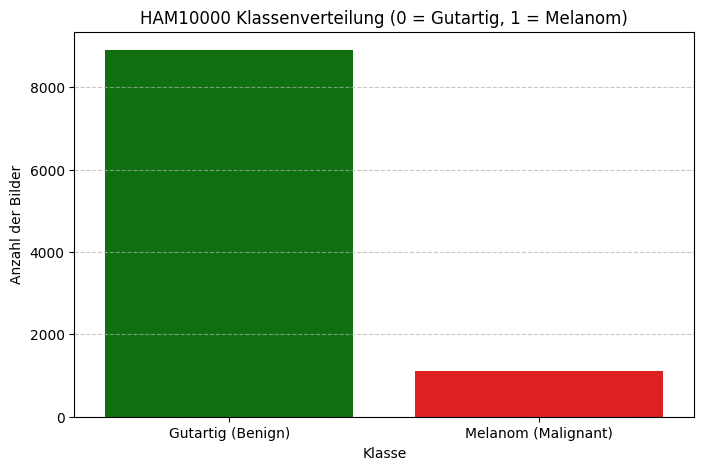

In [ ]:
# plot class distribution
def plotClassDistribution(dataset):
  plt.figure(figsize=(8, 5))
  sns.countplot(x='label', data=dataset, hue='label', palette=['green', 'red'], legend=False)
  plt.title('HAM10000 Class distribution (0 = benign, 1 = melanoma)')
  plt.xlabel('classs')
  plt.ylabel('Number of images')
  plt.xticks([0, 1], ['Benign', 'Malignant'])
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

plotClassDistribution(df)

# Split training, test and validation set

Trainings-Bilder: 7010
Validation-Bilder: 1002
Test-Bilder: 2003


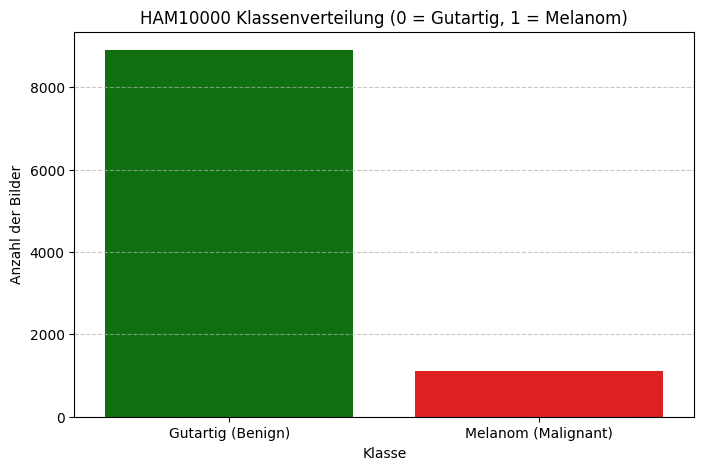

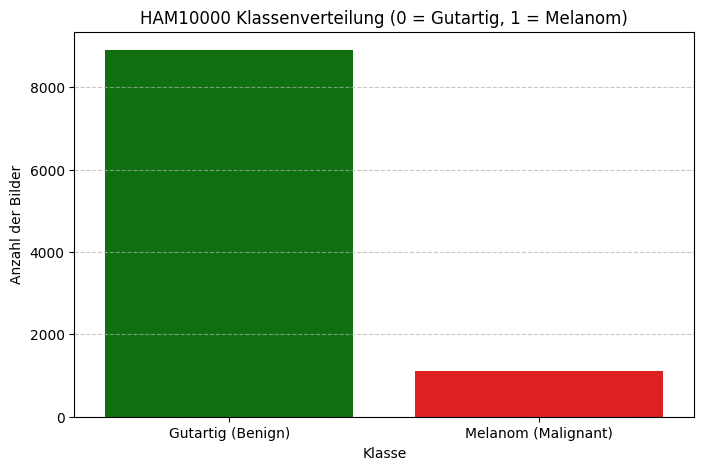

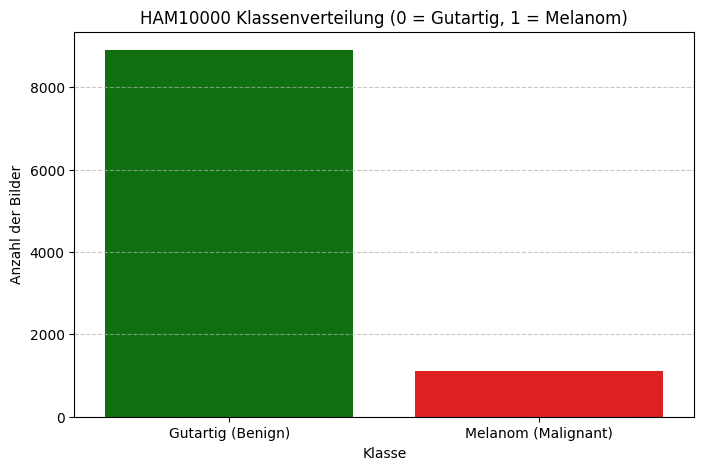

In [ ]:

train_val_df, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=random_state) # set seed

# von den 80% werden 12,5% abgezogen
train_df, val_df = train_test_split(train_val_df, test_size=0.125, stratify=train_val_df['label'], random_state=random_state)

print(f"training set: {len(train_df)}")
print(f"validation set: {len(val_df)}")
print(f"test set: {len(test_df)}")

dataset = [train_df, val_df, test_df]

for df_split in dataset:
  plotClassDistribution(df_split)
  # plt.figure(figsize=(8, 5))
  # sns.countplot(x='label', data=df, hue='label', palette=['green', 'red'], legend=False)  ##comment Fenya: df is wrong? must be df_split?
  # plt.title('HAM10000 Klassenverteilung (0 = Gutartig, 1 = Melanom)')
  # plt.xlabel('Klasse')
  # plt.ylabel('Anzahl der Bilder')
  # plt.xticks([0, 1], ['Gutartig (Benign)', 'Melanom (Malignant)'])
  # plt.grid(axis='y', linestyle='--', alpha=0.7)
  # plt.show()

# Data preprocessing

Lade Originalbild für ID: ISIC_0026062.jpg ...


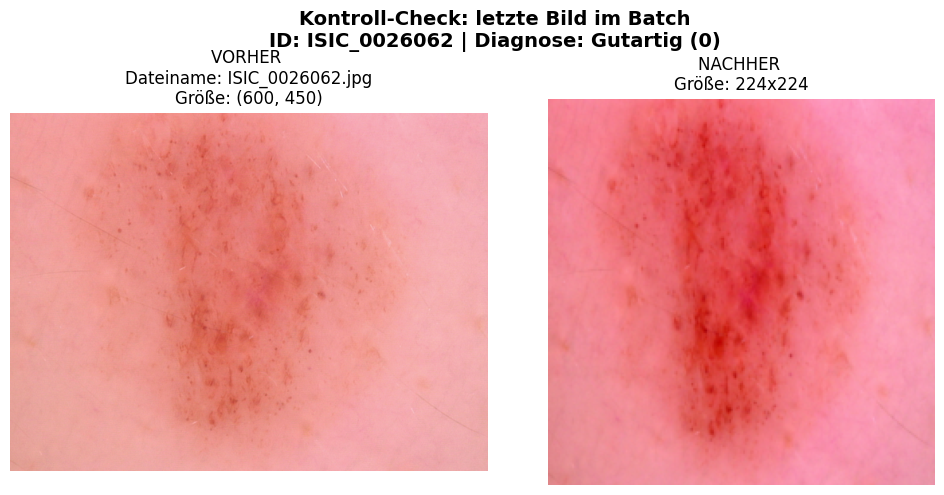

Gesuchte ID: ISIC_0026062
Eintrag in der CSV:
          image_id  label
4364  ISIC_0026062      0

 Stimmt mit der CSV überein
ok


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# EfficientNet-B0 will 224x224 andere resolution sind auch möglich und ImageNet-Normalisierung
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # soll gegen overfitting helfen
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset-Klasse
class SkinDataset(Dataset):
    def __init__(self, dataframe, img_dirs, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.loc[idx, 'image_id']
        img_name = img_id + '.jpg'
        img_path = None

        # In beiden Ordnern suchen
        for directory in self.img_dirs:
            temp_path = os.path.join(directory, img_name)
            if os.path.exists(temp_path):
                img_path = temp_path
                break

        if img_path is None:
            raise FileNotFoundError(f"Bild {img_name} nicht gefunden!")

        image = Image.open(img_path).convert('RGB')
        label = self.data.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        # PyTorch erwartet Labels als Float für den binären Loss (BCEWithLogitsLoss)
        return image, torch.tensor(label, dtype=torch.float32), img_id

# Pfade zu den Bildern
bild_ordner = [
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_images_part_1',
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_images_part_2'
]

# Datensätze erstellen
train_dataset = SkinDataset(train_df, bild_ordner, transform=train_transforms)
val_dataset = SkinDataset(val_df, bild_ordner, transform=test_transforms)
test_dataset = SkinDataset(test_df, bild_ordner, transform=test_transforms)

# DataLoader erstellen
b_size = 32
train_loader = DataLoader(train_dataset, batch_size=b_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=b_size, shuffle=False)

bilder, labels, bild_ids = next(iter(train_loader))

tensor_bild = bilder[-1]
label = labels[-1]
letzte_id = bild_ids[-1]  # Das ist z.B. "ISIC_0024306"

print(f"Lade Originalbild für ID: {letzte_id}.jpg ...")

# # NACHHER-BILD
bild_np = tensor_bild.numpy().transpose((1, 2, 0))
#mean = np.array([0.485, 0.456, 0.406])
#std = np.array([0.229, 0.224, 0.225])
#bild_np = std * bild_np + mean
minimum = bild_np.min()
maximum = bild_np.max()
bild_np = (bild_np - minimum) / (maximum - minimum)

# VORHER-BILD
img_name = letzte_id + '.jpg'

original_pfad = None
# Suchen im Google Drive Ordnern nach dem Bild
for directory in bild_ordner:
    temp_path = os.path.join(directory, img_name)
    if os.path.exists(temp_path):
        original_pfad = temp_path
        break

# Bilder anzeigen
if original_pfad:
    original_image = Image.open(original_pfad).convert('RGB')
    label_name = "Melanom (1)" if label.item() == 1.0 else "Gutartig (0)"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Kontroll-Check: letzte Bild im Batch\nID: {letzte_id} | Diagnose: {label_name}", fontsize=14, fontweight='bold')

    axes[0].imshow(original_image)
    axes[0].set_title(f"VORHER \nDateiname: {img_name}\nGröße: {original_image.size}", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(bild_np)
    axes[1].set_title(f"NACHHER \nGröße: {tensor_bild.shape[1]}x{tensor_bild.shape[2]}", fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Fehler: Konnte {img_name} auf dem Drive nicht finden!")

check_row = df[df['image_id'] == letzte_id]

print(f"Gesuchte ID: {letzte_id}")
print(f"Eintrag in der CSV:\n{check_row[['image_id', 'label']]}")

# Zusätzliche Bestätigung
csv_label = check_row['label'].values[0]
batch_label = int(label.item())

if csv_label == batch_label:
    print("\n Stimmt mit der CSV überein")
else:
    print("\n Unterscheidet sich von der CSV")

print("ok")